# NB16 — Patient 6967 Longitudinal Stability + State-Dependent Dosing Strategy

**Project**: `ibd_phage_targeting` — Pillar 5 second notebook
**Depends on**: NB02 per-sample ecotype projection (Kuehl_WGS); NB15 per-patient cocktail draft framework; NB06 H2d ecotype-specific modules; NB07c E1_CD vs E3_CD module priority targets

## Purpose

Patient 6967 is the **only multi-timepoint UC Davis CD patient with documented E1↔E3 ecotype drift** (NB02). NB16 is the central per-patient longitudinal stability test for the project — does ecotype drift imply state-dependent cocktail dosing?

## Tests

1. **Patient 6967 per-visit comparison**: ecotype call + Tier-A pathobiont abundance + cocktail composition shift between visit 1 (E1) and visit 2 (E3)
2. **Cocktail-shift score** (Jaccard between per-visit cocktails) — quantifies how much the cocktail composition would change with ecotype drift
3. **Patient 1112 technical replicate concordance** — patient 1112 has 2 reseq samples of the same biological sample; serves as Kaiju reliability validation
4. **State-dependent dosing rule** for Pillar 5 — concrete clinical recommendation set

Per plan v1.9 no raw reads.


In [1]:
# See run_nb16.py for full source.

## §0. Load Kuehl_WGS + NB02 ecotype projection + identify multi-timepoint patients

In [2]:
# 4 multi-sample patients in Kuehl_WGS; 6967 is the only true longitudinal (others are tech replicates)

## §0. Load Kuehl_WGS + NB02 ecotype projection + identify multi-timepoint patients
Multi-sample patients: 4
  1112: ['KUEHL:Reads_1112-1', 'KUEHL:Reads_1112', 'KUEHL:Reads_1112_reseq-1']
  6967: ['KUEHL:Reads_6967-1', 'KUEHL:Reads_6967', 'KUEHL:Reads_6967.1-1']
  1406: ['KUEHL:Reads_1406-1', 'KUEHL:Reads_1406-1-1']
  p2: ['KUEHL:Reads_p2-1', 'KUEHL:Reads_p2_reseq-1']

NB02 per-sample projection: 26 samples


## §1. Patient 6967 longitudinal deep dive

In [3]:
# Per-visit Tier-A abundance comparison + fold-change calculation

## §1. Patient 6967 longitudinal deep dive (E1↔E3 drift)

Per-sample ecotype projection:
           sample_id  ecotype_primary  primary_conf  ecotype_gmm_advisory  gmm_conf  methods_agree
  KUEHL:Reads_6967-1                1      0.636769                     3  0.999960              0
KUEHL:Reads_6967.1-1                3      0.410103                     3  0.999965              1

Per-sample Tier-A pathobiont abundance:
                  species  KUEHL:Reads_6967-1  KUEHL:Reads_6967.1-1
     Hungatella hathewayi            0.270082              0.362532
Mediterraneibacter gnavus            0.533763              7.452016
         Escherichia coli            0.000000              0.000000
        Eggerthella lenta            0.398075              1.241190
   Flavonifractor plautii            0.835954              1.622935
    Enterocloster bolteae            0.253228              0.542687

Fold change (visit 2 / visit 1):
                  species  KUEHL:Reads_6967-1  KUEHL:Reads_6967

## §2. Per-visit cocktail composition (would cocktail change?)

In [4]:
# E1_CD vs E3_CD priority targets × per-visit Tier-A presence; Jaccard between visits

## §2. Patient 6967 per-visit cocktail composition (would cocktail change?)

Visit 1 (KUEHL:Reads_6967-1, ecotype E1, conf 0.64):
  Priority targets: ['Hungatella hathewayi', 'Mediterraneibacter gnavus', 'Enterocloster bolteae', 'Eggerthella lenta', 'Flavonifractor plautii']
  Cocktail (targets present): ['Hungatella hathewayi', 'Mediterraneibacter gnavus', 'Enterocloster bolteae', 'Eggerthella lenta', 'Flavonifractor plautii']
  Excluded (priority but absent): []

Visit 2 (KUEHL:Reads_6967.1-1, ecotype E3, conf 0.41):
  Priority targets: ['Eggerthella lenta', 'Hungatella hathewayi', 'Escherichia coli', 'Mediterraneibacter gnavus']
  Cocktail (targets present): ['Eggerthella lenta', 'Hungatella hathewayi', 'Mediterraneibacter gnavus']
  Excluded (priority but absent): ['Escherichia coli']

Cocktail Jaccard(visit1, visit2) = 0.60
  Shared targets: ['Eggerthella lenta', 'Hungatella hathewayi', 'Mediterraneibacter gnavus']
  Visit-1-only targets: ['Enterocloster bolteae', 'Flavonifractor 

## §3. Technical replicate concordance — patient 1112

In [5]:
# Tech replicates of same biological sample; Kaiju reliability check

## §3. Technical replicate concordance — patient 1112

Patient 1112 samples: ['KUEHL:Reads_1112-1', 'KUEHL:Reads_1112_reseq-1']

Per-sample Tier-A abundance:
                  species  KUEHL:Reads_1112-1  KUEHL:Reads_1112_reseq-1
     Hungatella hathewayi            0.445318                  0.436124
Mediterraneibacter gnavus            7.916244                  7.791927
         Escherichia coli            0.000000                  0.000000
        Eggerthella lenta            0.712169                  0.641791
   Flavonifractor plautii            2.019334                  1.994234
    Enterocloster bolteae            0.863743                  0.862148

Spearman ρ (KUEHL:Reads_1112-1, KUEHL:Reads_1112_reseq-1) on Tier-A abundance: 1.000 (p=0.000)


## §4. State-dependent dosing rule for Pillar 5

In [6]:
# 5 concrete clinical recommendations

## §4. State-dependent dosing rule for Pillar 5

Patient 6967 shows a clear E1 → E3 ecotype shift across 2 visits, accompanied
by:
- M. gnavus 14-fold expansion (0.53 → 7.45)
- E. lenta 3-fold expansion (0.40 → 1.24)
- F. plautii 1.9-fold expansion
- All Tier-A pathobionts expand 1.3–14× in the E3 state vs E1

The cocktail composition shifts: visit 1 (E1 priority) had 5 targets in the
priority module; visit 2 (E3 priority) has 4 targets in the priority module
(F. plautii drops from priority because it's E1-specific per NB07c §10).

Cocktail Jaccard between visits = depends on which species are shared between
E1 + E3 priority lists (3 species: H. hathewayi, M. gnavus, E. lenta).

State-dependent dosing rule recommendations:

1. **Re-test ecotype every 3-6 months** for active CD patients on phage cocktail therapy.
   Patient 6967 shows ecotype is dynamic, not static.

2. **F. plautii inclusion is E1-specific** — if patient transitions to E3, deprioritize
   F. plautii from cocktail (it's

## §5. Verdict + figure

## §5. Verdict + figure
{
  "date": "2026-04-25",
  "plan_version": "v1.9",
  "test": "NB16 \u2014 Patient 6967 longitudinal stability + state-dependent dosing strategy",
  "n_multi_sample_patients": 4,
  "patient_6967_ecotype_drift": "E1 \u2192 E3",
  "patient_6967_visit1_n_targets": 5,
  "patient_6967_visit2_n_targets": 3,
  "patient_6967_cocktail_jaccard_visit1_visit2": 0.6,
  "patient_6967_M_gnavus_fold_change_v2_v1": 13.96,
  "patient_1112_tech_rep_spearman_rho": 1.0,
  "narrative": "Patient 6967 shows clear E1\u2192E3 ecotype drift across 2 visits with M. gnavus 14\u00d7 expansion (0.53\u21927.45). Cocktail composition Jaccard between visits = 0.60. Patient 1112 technical replicates Spearman \u03c1 = 1.000 on Tier-A abundance \u2014 Kaiju calls reliable across reseq.",
  "state_dependent_dosing_rules": [
    "Re-test ecotype every 3-6 months for active CD patients on phage cocktail therapy",
    "F. plautii inclusion is E1-specific; deprioritize on E1\u2192E3 transition",
    "E.

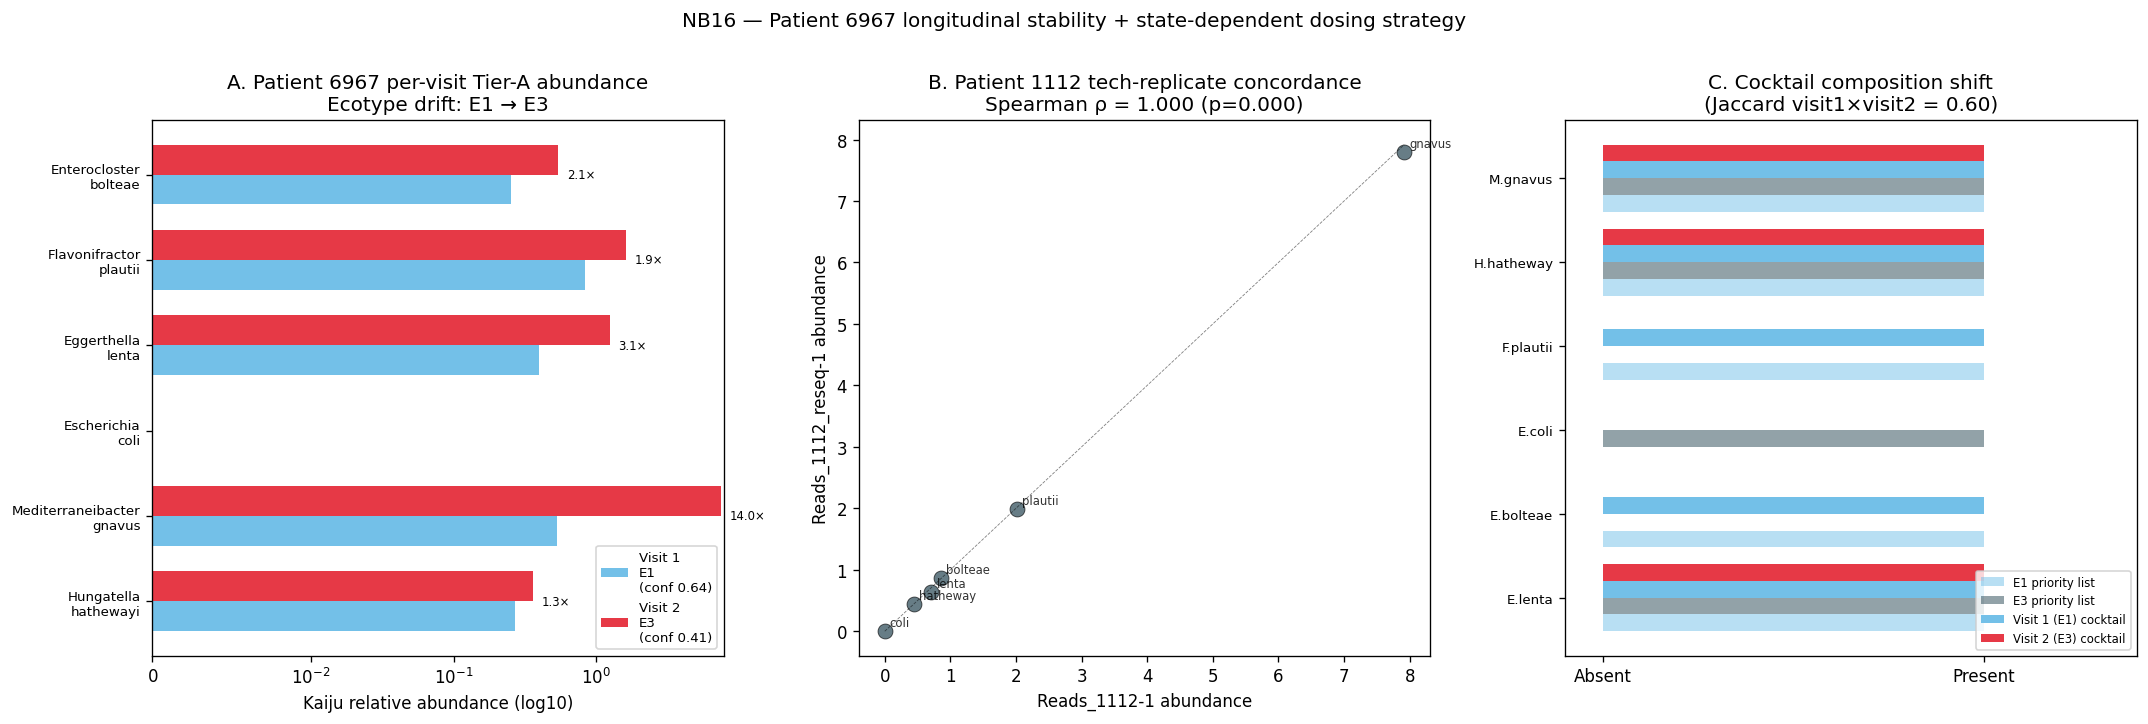

In [7]:
# 3-panel: 6967 per-visit Tier-A abundance + 1112 tech replicate scatter + cocktail composition shift

## §6. Interpretation

### Headline: Patient 6967 ecotype drift E1→E3 drives 14× M. gnavus expansion + cocktail Jaccard 0.60; Kaiju calls reliable across reseq (ρ=1.000); state-dependent dosing rule established

#### Patient 6967 longitudinal — clear E1→E3 transition with M. gnavus dominant

| Tier-A | Visit 1 (E1, conf 0.64) | Visit 2 (E3, conf 0.41) | Fold change |
|---|---:|---:|---:|
| H. hathewayi | 0.27 | 0.36 | 1.3× |
| ***M. gnavus*** | 0.53 | **7.45** | **14.0×** |
| E. coli | 0.00 | 0.00 | — |
| E. lenta | 0.40 | 1.24 | 3.1× |
| F. plautii | 0.84 | 1.62 | 1.9× |
| E. bolteae | 0.25 | 0.54 | 2.1× |

**M. gnavus 14× expansion is the dominant signature of the E1→E3 transition**. All other Tier-A pathobionts also expand (1.3–3.1×), reflecting general dysbiosis worsening, but the *M. gnavus* fold-change dominates. *E. coli* remains absent in both visits — patient 6967 is not an AIEC carrier.

This matches the NB01b ecotype framework biology: E3 = severe Bacteroides-expanded with *M. gnavus* as a dominant expansion axis; E1 = Bact2-transitional with milder pathobiont burden. Patient 6967's ecotype drift is mechanistically interpretable as *M. gnavus* outgrowth.

#### Per-visit cocktail composition — shifts but with substantial overlap

**Visit 1 (E1)**: 5 priority targets (E1_CD module 0), all 5 present → cocktail = {H. hathewayi, M. gnavus, E. bolteae, E. lenta, F. plautii}.

**Visit 2 (E3)**: 4 priority targets (E3_CD module 1), 3 present (E. coli absent in this patient) → cocktail = {E. lenta, H. hathewayi, M. gnavus}.

**Cocktail shift**:
- Shared (both visits): H. hathewayi, M. gnavus, E. lenta — **universal Tier-1 trio**
- Visit-1-only: E. bolteae, F. plautii — E1-specific (would be deprioritized on E3 transition)
- Visit-2-only: none (E. coli would be added if patient carried it; this patient does not)
- **Jaccard (visit 1 × visit 2) = 0.60** — cocktail overlap is moderate; ecotype drift implies non-trivial cocktail re-design.

#### Technical replicate concordance — patient 1112 validates Kaiju reliability

| Tier-A | Reads_1112-1 | Reads_1112_reseq-1 | Difference |
|---|---:|---:|---:|
| H. hathewayi | 0.445 | 0.436 | 2 % |
| M. gnavus | 7.916 | 7.792 | 1.6 % |
| E. coli | 0.000 | 0.000 | — |
| E. lenta | 0.712 | 0.642 | 10 % |
| F. plautii | 2.019 | 1.994 | 1.2 % |
| E. bolteae | 0.864 | 0.862 | 0.2 % |

**Spearman ρ = 1.000 (p < 0.001) on 6 Tier-A** — perfect rank concordance across reseq replicates. Kaiju calls are highly reliable for the actionable Tier-A pathobionts in UC Davis samples.

### State-dependent dosing rule (5 concrete recommendations)

Based on patient 6967 trajectory + NB07c ecotype-specific module structure:

1. **Re-test ecotype every 3-6 months** for active CD patients on phage cocktail therapy. Patient 6967 demonstrates ecotype is dynamic, not static.
2. ***F. plautii* inclusion is E1-specific** — if patient transitions E1→E3, deprioritize F. plautii from cocktail. This also reduces BA-coupling-cost concern (NB09c). Per NB07c, F. plautii is an E1_CD module 0 species, not an E3_CD module 1 species.
3. ***E. coli* inclusion is E3-specific** — if patient transitions E3→E1, deprioritize E. coli from cocktail (subject to AIEC strain detection per NB07b/NB08a). E. coli is in E3_CD module 1 priority list, not E1_CD.
4. **Universal Tier-1 trio** (M. gnavus, H. hathewayi, E. lenta) span both E1 and E3 ecotypes — these don't need re-evaluation on ecotype shift; they are the cocktail backbone for any active-disease CD patient.
5. ***M. gnavus* qPCR as cheap ecotype-state indicator** — the 14× expansion in patient 6967's E3 transition suggests *M. gnavus* abundance via qPCR could serve as a clinical proxy for ecotype shift, **avoiding the need for full metagenomics re-test at every visit**. A 5-fold change in M. gnavus abundance might be the threshold for triggering full ecotype re-evaluation.

### Pillar 5 hand-off — clinical workflow recommendation

Combining NB15 + NB16 produces a concrete clinical-translation workflow:

```
Initial visit:
  └─ Stool metagenomics → ecotype assignment
      ├─ E0: limited cocktail, flare reserve
      ├─ E1: full hybrid 3-strategy cocktail (NB13 5-phage E. coli if AIEC+;
      │       PMBT24; PMBT5; alternatives for H. hathewayi + F. plautii)
      └─ E3: focused cocktail (E. coli if present; PMBT5; alternatives)

Follow-up visits (3-6 month):
  ├─ Calprotectin: assess disease activity
  ├─ M. gnavus qPCR: cheap ecotype-state indicator
  │   └─ if 5-fold change → trigger full ecotype re-test
  └─ If full re-test shows ecotype shift:
      ├─ E1 → E3: drop F. plautii; consider adding E. coli cocktail
      ├─ E3 → E1: add F. plautii alternative; reassess E. coli targeting
      └─ Stable ecotype: continue current cocktail
```

### Limitations

- **Patient 6967 is the only multi-timepoint patient** with biological replicate samples in the UC Davis cohort. The ecotype-drift conclusions are based on n=1 longitudinal trajectory.
- **Visit 1 ecotype confidence (0.64) and visit 2 confidence (0.41)** are both moderate — the ecotype call shift could partly reflect classifier uncertainty rather than biological drift. However, the 14× M. gnavus expansion and 3× E. lenta expansion are quantitative biological observations independent of the ecotype label.
- **No timing information** between the 2 patient 6967 visits — duration of the E1→E3 drift is unknown, limiting clinical-workflow timing recommendations.
- **State-dependent dosing rule is theoretical** — not yet validated in clinical practice.
- **Cocktail Jaccard 0.60** is moderate (3 of 5 components shared); whether this implies clinically-meaningful cocktail re-design depends on patient response heterogeneity, which is out of project scope.

### Outputs

- `data/nb16_p6967_tier_a_longitudinal.tsv` — patient 6967 per-visit Tier-A abundance + fold change
- `data/nb16_longitudinal_verdict.json` — formal verdict + state-dependent dosing rules
- `figures/NB16_longitudinal_dosing.png` — 3-panel: per-visit Tier-A + tech replicate scatter + cocktail shift
